# INFORM localization test — `nerve_1` vs `nerve_1_shifted`



## 1. Imports

In [18]:
from pathlib import Path
import pickle
import time
import sys
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import numpy as np

from sklearn.gaussian_process.kernels import Matern
from sklearn.preprocessing import StandardScaler

from nerve_model.experiment import Experiment
from nerve_model.fiber_population import MotorFiberPopulation

from localization.candidate_generation import create_loc_candidates
from localization.bayesian_localization import performLocalizationCluster
from localization.visualization import (
    plot_recruitment_extended,
    plot_recruitment_superposed,
)


# ------------------------------------------------------------------
# Backward compatibility for old pickle files
# ------------------------------------------------------------------

import nerve_model.experiment as experiment
import nerve_model.fiber_population as fiber_population
import nerve_model.nerve_section as nerve_section
import nerve_model.recruitment_curves as recruitment_curves
import nerve_model.implant as implant

sys.modules["experiment"] = experiment
sys.modules["fiber_population"] = fiber_population
sys.modules["nerve_section"] = nerve_section
sys.modules["recruitment_curves"] = recruitment_curves
sys.modules["implant"] = implant

# ------------------------------------------------------------------

np.set_printoptions(suppress=True)

print("Imports OK")


Imports OK


## 2. Parameters

Modify `PROJECT_FOLDER`

In [7]:
# Root folder containing "Median nerve/experiments" and "Median nerve/surrogate_experiments"
PROJECT_FOLDER = Path(r"C:/Users/laura/OneDrive/Desktop/Projects/Models")

# True and inferred nerve folders
TRUE_NERVE_FOLDER = "nerve_1"
INFERRED_NERVE_FOLDER = "nerve_1_shifted"

# Population / trial
POPULATION_ID = 1
N_TRIAL = "cross"

# Recruitment curve parameters
N_STIMS_PER_SITE = 20
MIN_STIM = 0
MAX_STIM = 1 #mA

# Bayesian localization parameters
MAX_ITER = 20
BATCH_SIZE = 1
TRADEOFF = 0.1

# Candidate grid parameters
STD_LIMS = (0.1, 0.5)
NUM_LIMS = (200, 200)
N_TRIES_LOCS = (20, 20)
N_TRIES_STD = 20
N_TRIES_NUM = 20

COLOR_LIST = [
    "#1f78b4",
    "#ee7674",
    "#F6BD60",
    "#8dd3c7",
    "#e31a1c",
    "#cab2d6",
]

print("Parameters set")

Parameters set


## 3. Paths

In [8]:
surrogate_base_path = (
    PROJECT_FOLDER
    / "Median nerve"
    / "surrogate_experiments"
    / INFERRED_NERVE_FOLDER
    / N_TRIAL
)

true_base_path = (
    PROJECT_FOLDER
    / "Median nerve"
    / "experiments"
    / TRUE_NERVE_FOLDER
    / N_TRIAL
)

inf_experiment_path = surrogate_base_path / f"experiment_trial_{N_TRIAL}.pkl"
true_experiment_path = true_base_path / f"experiment_pop_{POPULATION_ID}trial_{N_TRIAL}.pkl"

results_folder = surrogate_base_path / "results"
results_folder.mkdir(parents=True, exist_ok=True)

print("Inferred experiment:", inf_experiment_path)
print("True experiment:", true_experiment_path)
print("Results folder:", results_folder)

assert inf_experiment_path.exists(), f"Missing file: {inf_experiment_path}"
assert true_experiment_path.exists(), f"Missing file: {true_experiment_path}"

print("Paths OK")

Inferred experiment: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\surrogate_experiments\nerve_1_shifted\cross\experiment_trial_cross.pkl
True experiment: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\experiments\nerve_1\cross\experiment_pop_1trial_cross.pkl
Results folder: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\surrogate_experiments\nerve_1_shifted\cross\results
Paths OK


## 4. Load experiments

In [9]:
with open(inf_experiment_path, "rb") as f:
    full_inf_experiment = pickle.load(f)

with open(true_experiment_path, "rb") as f:
    true_experiment = pickle.load(f)

print("Inferred full experiment:")
print(full_inf_experiment)

print("\nTrue experiment:")
print(true_experiment)

n_clusters = true_experiment.fiber_population.n_groups
print("\nNumber of clusters:", n_clusters)
print("Number of sites:", true_experiment.implant.n_sites)

Inferred full experiment:
Experiment(n_fibers=3600, n_sites=9, lead_field_matrix_loaded=True, activation_predictor_loaded=True)

True experiment:
Experiment(n_fibers=800, n_sites=9, lead_field_matrix_loaded=True, activation_predictor_loaded=True)

Number of clusters: 4
Number of sites: 9


## 5. Plot true and inferred nerve structures

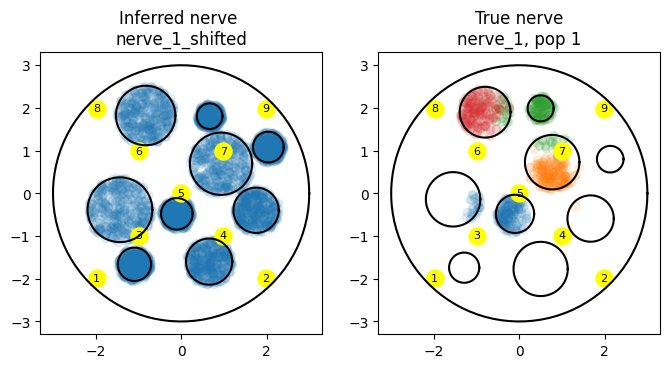

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

full_inf_experiment.nerve_topography.plot(ax=ax[0])
full_inf_experiment.fiber_population.plot(ax=ax[0])
full_inf_experiment.implant.plot(ax=ax[0])
full_inf_experiment.implant.plot_text(ax=ax[0])
ax[0].set_title("Inferred nerve \nnerve_1_shifted")
ax[0].set_aspect("equal")

true_experiment.nerve_topography.plot(ax=ax[1])
true_experiment.fiber_population.plot(ax=ax[1])
true_experiment.implant.plot(ax=ax[1])
true_experiment.implant.plot_text(ax=ax[1])
ax[1].set_title("True nerve\nnerve_1, pop 1")
ax[1].set_aspect("equal")

plt.show()

## 6. Compute reference recruitment curves

True recruitment curves shape: (9, 4, 20)
Amplitudes shape: (20,)


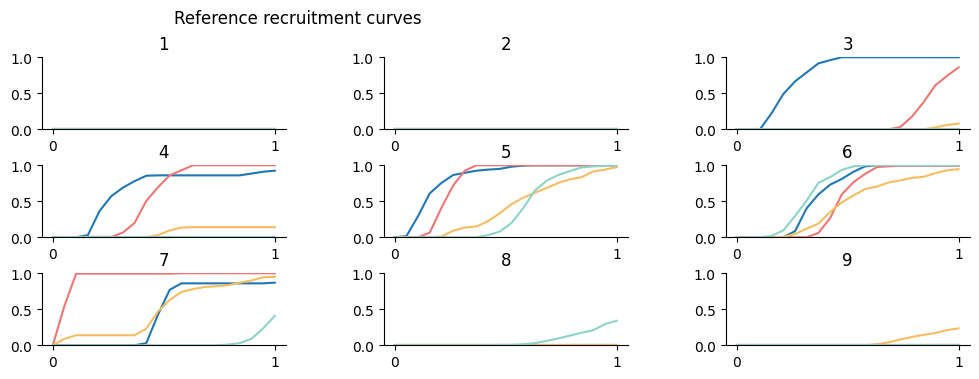

In [15]:
amp_lims = [MIN_STIM, MAX_STIM]

true_recruitment_curves_obj = true_experiment.generate_recruitment_curves(
    amp_lims=amp_lims,
    n_steps=N_STIMS_PER_SITE,
    method="from_self",
)

n_sites = true_recruitment_curves_obj.n_sites
amplitudes = true_recruitment_curves_obj.amplitudes
true_recruitment_curves = true_recruitment_curves_obj.recruitment_values

print("True recruitment curves shape:", true_recruitment_curves.shape)
print("Amplitudes shape:", np.asarray(amplitudes).shape)

fig, _ = plot_recruitment_extended(
    true_recruitment_curves=true_recruitment_curves,
    n_clusters=n_clusters,
    amplitudes=amplitudes,
    n_sites=n_sites,
    title="Reference recruitment curves",
)
plt.show()

## 7. Create localization candidates

In [16]:
nerve_radius = full_inf_experiment.nerve_topography.nerve_radius

candidates_grid = create_loc_candidates(
    nerve_radius=nerve_radius,
    limCandidateStd=STD_LIMS,
    limCandidateNum=NUM_LIMS,
    nTriesLocs=N_TRIES_LOCS,
    nTriesStd=N_TRIES_STD,
    nTriesNum=N_TRIES_NUM,
)

scaler = StandardScaler()
standardized_candidates_grid = scaler.fit_transform(candidates_grid)

print("Nerve radius:", nerve_radius)
print("Candidates grid shape:", candidates_grid.shape)
print("Standardized candidates shape:", standardized_candidates_grid.shape)
print(candidates_grid[:5])

Nerve radius: 3
Candidates grid shape: (110400, 4)
Standardized candidates shape: (110400, 4)
[[ -1.10526316  -2.68421053   0.1        200.        ]
 [ -1.10526316  -2.68421053   0.1        200.        ]
 [ -1.10526316  -2.68421053   0.1        200.        ]
 [ -1.10526316  -2.68421053   0.1        200.        ]
 [ -1.10526316  -2.68421053   0.1        200.        ]]


## 8. Run Bayesian localization

In [19]:
experiment_info = {
    "full_experiment": full_inf_experiment,
    "full_lfm": full_inf_experiment.lead_field_matrix,
    "amp_lims": np.array(amp_lims),
    "n_stims_per_site": N_STIMS_PER_SITE,
}

kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0],
    nu=2.5,
    length_scale_bounds=(1e-5, float("inf")),
)

X_clust = [None for _ in range(n_clusters)]
Y_clust = [None for _ in range(n_clusters)]
rc_clust = [None for _ in range(n_clusters)]
X_max_clust = [None for _ in range(n_clusters)]
Y_max_clust = [None for _ in range(n_clusters)]
acq_clust = [None for _ in range(n_clusters)]
YPrior = [None for _ in range(n_clusters)]

priorX = []
priorRC = []
priorExp = []

start = time.time()

for clust in tqdm(range(n_clusters), desc="Localizing clusters"):
    refCurves = true_recruitment_curves[:, clust:clust + 1, :]

    if clust == 0:
        priorInfoX = None
        rcPrior = None
    else:
        priorX = priorX + X_clust[clust - 1]
        priorRC = priorRC + rc_clust[clust - 1]
        priorInfoX = priorX
        rcPrior = priorRC

    (
        X_clust[clust],
        Y_clust[clust],
        rc_clust[clust],
        X_max_clust[clust],
        Y_max_clust[clust],
        acq_clust[clust],
        YPrior[clust],
    ) = performLocalizationCluster(
        experiment_info=experiment_info,
        refCurves=refCurves,
        candidatesGrid=candidates_grid,
        candidatesGridStandardized=standardized_candidates_grid,
        kernel=kernel,
        tr=TRADEOFF,
        maxIter=MAX_ITER,
        batchSize=BATCH_SIZE,
        priorInfoX=priorInfoX,
        rcPrior=rcPrior,
    )

end = time.time()
print(f"Elapsed time: {end - start:.2f} s")

Localizing clusters:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

4
5.730669390627812e-13
-0.009777916666666666


  0%|          | 0/200 [00:00<?, ?it/s]

2
5.173994719416471e-10
-0.007229166666666666


  0%|          | 0/200 [00:00<?, ?it/s]

2
6.013709202378108e-09
-0.002167777777777777
Elapsed time: 69.74 s


## 9. Extract inferred cluster parameters and localization errors

In [20]:
mean_locs_x = true_experiment.fiber_population.cluster_locs[:, 0]
mean_locs_y = true_experiment.fiber_population.cluster_locs[:, 1]
new_std = true_experiment.fiber_population.cluster_std

xReal = [None for _ in range(n_clusters)]
yReal = [None for _ in range(n_clusters)]
stdReal = [None for _ in range(n_clusters)]
numReal = [None for _ in range(n_clusters)]

distError = [None for _ in range(n_clusters)]
stdError = [None for _ in range(n_clusters)]
numError = [None for _ in range(n_clusters)]

for i in range(n_clusters):
    xRef = true_experiment.fiber_population.cluster_locs[i][0]
    yRef = true_experiment.fiber_population.cluster_locs[i][1]
    stdRef = true_experiment.fiber_population.cluster_std[i]
    numRef = true_experiment.fiber_population.cluster_num[i]

    best_candidate_std = X_max_clust[i][-1].reshape(1, -1)
    best_candidate = scaler.inverse_transform(best_candidate_std)[0]

    xReal[i] = best_candidate[0]
    yReal[i] = best_candidate[1]
    stdReal[i] = best_candidate[2]
    numReal[i] = best_candidate[3]

    distError[i] = np.sqrt((xRef - xReal[i]) ** 2 + (yRef - yReal[i]) ** 2)
    stdError[i] = abs(stdRef - stdReal[i]) / stdRef
    numError[i] = abs(numRef - numReal[i]) / numRef

cluster_locs_inf = np.column_stack((xReal, yReal))
cluster_std_inf = np.asarray(stdReal)
cluster_num_inf = np.asarray(numReal)

print("Inferred cluster locations:")
print(cluster_locs_inf)

print("\nInferred std:")
print(cluster_std_inf)

print("\nInferred num:")
print(cluster_num_inf)

print("\nDistance errors:")
print(distError)

print("\nRelative std errors:")
print(stdError)

Inferred cluster locations:
[[-0.47368421 -0.15789474]
 [ 0.78947368  0.47368421]
 [ 0.15789474  2.68421053]
 [-1.10526316  2.68421053]]

Inferred std:
[0.5        0.16315789 0.1        0.5       ]

Inferred num:
[200. 200. 200. 200.]

Distance errors:
[0.3328644261721751, 0.13837562357700867, 0.6536916091346688, 0.7463406898317253]

Relative std errors:
[0.7823532533064641, 0.30676404998333306, 0.7559991948893187, 0.47474950428463164]


## 10. Build inferred population and experiment

In [21]:
inf_population, inf_identities = MotorFiberPopulation.from_existing_population(
    cluster_locs=cluster_locs_inf,
    cluster_std=cluster_std_inf,
    cluster_num=cluster_num_inf.astype(int),
    fiber_population=full_inf_experiment.fiber_population,
)


inf_identities = inf_identities.astype(int)

inf_experiment = Experiment(
    fiber_population=inf_population,
    nerve_topography=full_inf_experiment.nerve_topography,
    implant=full_inf_experiment.implant,
)


inf_experiment._activation_predictor = full_inf_experiment.activation_predictor

inf_lfm = inf_experiment.load_lead_field_matrix(
    full_experiment=full_inf_experiment,
    lead_field_matrix=full_inf_experiment.lead_field_matrix,
    identities=inf_identities,
    save_to_hdf5=False,
)

inf_recruitment_curves_obj = inf_experiment.generate_recruitment_curves(
    amp_lims=np.array(amp_lims),
    n_steps=N_STIMS_PER_SITE,
    method="from_self",
)

print("Inferred recruitment curves shape:", inf_recruitment_curves_obj.recruitment_values.shape)

  0%|          | 0/800 [00:00<?, ?it/s]

Inferred recruitment curves shape: (9, 4, 20)


## 11. Plot final localization and inferred recruitment curves

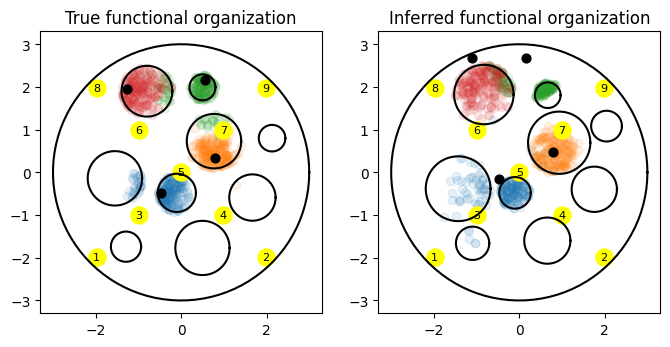

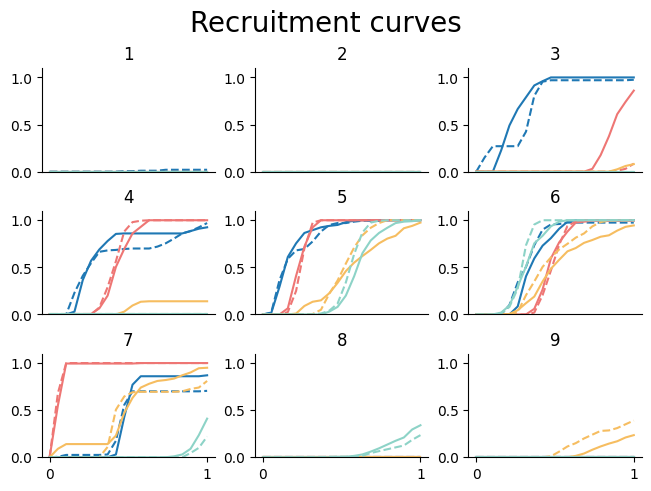

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

true_experiment.nerve_topography.plot(ax=ax[0])
true_experiment.fiber_population.plot(ax=ax[0])
true_experiment.implant.plot(ax=ax[0])
true_experiment.implant.plot_text(ax=ax[0])
ax[0].scatter(mean_locs_x, mean_locs_y, c="black", s=40)
ax[0].set_title("True functional organization")
ax[0].set_aspect("equal")



inf_experiment.nerve_topography.plot(ax=ax[1])
inf_experiment.fiber_population.plot(ax=ax[1])
inf_experiment.implant.plot(ax=ax[1])
inf_experiment.implant.plot_text(ax=ax[1])
ax[1].scatter(cluster_locs_inf[:, 0], cluster_locs_inf[:, 1], c="black", s=40)
ax[1].set_title("Inferred functional organization")
ax[1].set_aspect("equal")

plt.show()

inf_recruitment_curves = inf_recruitment_curves_obj.recruitment_values

fig, _ = plot_recruitment_superposed(
    true_recruitment_curves=true_recruitment_curves,
    pred_recruitment_curves=inf_recruitment_curves_obj.recruitment_values,
    amplitudes=np.linspace(MIN_STIM, MAX_STIM, N_STIMS_PER_SITE),
    n_sites=true_recruitment_curves.shape[0],
    n_clusters=true_recruitment_curves.shape[1],
    title="Recruitment curves",
)
plt.show()

## 12. Save results

In [25]:
results_filename = f"results_{N_TRIAL}_pop_{POPULATION_ID}_inexact_structure.pkl"
save_file_name = results_folder / results_filename

with open(save_file_name, "wb") as f:
    pickle.dump(
        [
            mean_locs_x,
            mean_locs_y,
            new_std,
            true_recruitment_curves,
            MAX_STIM,
            N_STIMS_PER_SITE,
            standardized_candidates_grid,
            scaler,
            candidates_grid,
            X_clust,
            Y_clust,
            X_max_clust,
            Y_max_clust,
            acq_clust,
            YPrior,
            priorX,
            priorExp,
            inf_experiment,
            inf_recruitment_curves,
            inf_identities,
        ],
        f,
    )

print("Saved:", save_file_name)

Saved: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\surrogate_experiments\nerve_1_shifted\cross\results\results_cross_pop_1_inexact_structure.pkl
